<a href="https://colab.research.google.com/github/NikolaiMiranda/customer-segmentation-retail/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install and Import Packages:

In [78]:
# Import packages
import pandas as pd
from datetime import timedelta
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import davies_bouldin_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
from sklearn.decomposition import PCA

# Gather and clean data:

In [79]:
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# create a dataframe to hold the data
# reading through the documentation for ucimlrepo we find that our data is split into dataframe labeled "ids" and "features"
# we will join those together to form one dataframe
# Check that both dataframes are the same length and then join them
print(len(online_retail.data.ids) == len(online_retail.data.features))
df = online_retail.data.ids.join(online_retail.data.features)

True


In [80]:
# View the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [81]:
# Check if we have null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [82]:
# We have missing cutomer IDs
# We remove these since we need the IDs to match customers to their purchases and segment them
df = df.dropna(subset=['CustomerID'])

# Check to make sure null values have been discarded
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [83]:
# The documentation states that if an order is cancelled the InvoiceNo will start with a 'C'
# We will remove all canceled orders from the data since we want to segment customers based on their purchases.
# Let us look at an example of a cancelled order.
df[df['CustomerID'] == 12346]
# We must match all cancelled orders to their original orders and then remove them.
# If the cancelled quanitity equals the original quanitity, delete both orders.
# If the cancelled quantity is less than the original quantity, subtract the cancelled quantity from the original quanitity and delete the separate cancelled transaction.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.0,United Kingdom


In [84]:
# Write a function that strips the dataframe of the cancelled orders and adjusts quantities accordingly
def remove_cancellations(df):
    """
    Adjust quantities in a DataFrame by subtracting matching cancellations.
    If quantity becomes zero or negative after cancellation, the row is removed.

    Parameters:
        df (pd.DataFrame): Must contain 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
                           'UnitPrice', 'CustomerID', and 'Country' columns.

    Returns:
        pd.DataFrame: Adjusted DataFrame with cancellations removed/quantities updated.
    """
    # Separate cancellations and originals
    df_cancel = df[df['InvoiceNo'].str.startswith('C')].copy()
    df_cancel['Quantity'] = df_cancel['Quantity'].abs()

    df_original = df[~df['InvoiceNo'].str.startswith('C')].copy()

    # Group cancellations so multiple cancels get summed together
    matching_cols = ['StockCode', 'Description', 'UnitPrice', 'CustomerID', 'Country']
    df_cancel_grouped = (
        df_cancel
        .groupby(matching_cols, as_index=False)['Quantity']
        .sum()
        .rename(columns={'Quantity': 'Quantity_cancel'})
    )

    # Merge grouped cancellations into originals
    df_cleaned = pd.merge(
        df_original,
        df_cancel_grouped,
        on=matching_cols,
        how='left'
    )

    # Adjust quantities
    df_cleaned['Quantity_cancel'] = df_cleaned['Quantity_cancel'].fillna(0)
    df_cleaned['Quantity'] = df_cleaned['Quantity'] - df_cleaned['Quantity_cancel']

    # Remove zero/negative quantities
    df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0].copy()

    # Drop temp col & reset index
    df_cleaned.drop(columns=['Quantity_cancel'], inplace=True)
    df_cleaned.reset_index(drop=True, inplace=True)

    return df_cleaned

In [85]:
# Test suite for our remove_cancellations() function
def test_remove_cancellations():
    # Create synthetic test data
    data = [
        ['10001', 'A1', 'Widget', 10, '2025-08-01', 2.0, 111, 'UK'],   # full cancel
        ['10002', 'B2', 'Gadget', 5,  '2025-08-01', 3.0, 222, 'UK'],   # partial cancel
        ['10003', 'C3', 'Thingy', 8,  '2025-08-01', 4.0, 333, 'UK'],   # no cancel
        ['C10001', 'A1', 'Widget', -10, '2025-08-02', 2.0, 111, 'UK'], # full cancel
        ['C10002', 'B2', 'Gadget', -2,  '2025-08-02', 3.0, 222, 'UK'], # first partial cancel
        ['C10002b','B2', 'Gadget', -1,  '2025-08-03', 3.0, 222, 'UK'], # second partial cancel
    ]
    df = pd.DataFrame(data, columns=[
        'InvoiceNo', 'StockCode', 'Description', 'Quantity',
        'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'
    ])

    # Run function
    df_adjusted = remove_cancellations(df)

    # Automated Checks
    print("\n=== TEST RESULTS ===")
    tests_passed = True

    # Expected results
    expected = {
        'A1': None,     # fully cancelled, should be removed
        'B2': 2,        # started with 5, cancelled total 3
        'C3': 8         # unchanged
    }

    # Check 1: No cancellations remain
    if (df_adjusted['InvoiceNo'].str.startswith('C').any()):
        print("Cancellations still present in adjusted data!")
        tests_passed = False

    # Check 2: Quantities match expectations
    for stock, qty in expected.items():
        actual_qtys = df_adjusted.loc[df_adjusted['StockCode'] == stock, 'Quantity']
        if qty is None:
            if not actual_qtys.empty:
                print(f"{stock} should be removed but is still present.")
                tests_passed = False
        else:
            if actual_qtys.empty or actual_qtys.iloc[0] != qty:
                print(f"{stock} expected qty {qty} but got {actual_qtys.iloc[0] if not actual_qtys.empty else 'MISSING'}.")
                tests_passed = False

    # Check 3: No zero-quantity rows
    if (df_adjusted['Quantity'] == 0).any():
        print("Zero quantities found in adjusted data!")
        tests_passed = False

    if tests_passed:
        print("All tests passed!")
    else:
        print("Some tests failed.")


# Run the test
test_remove_cancellations()


=== TEST RESULTS ===
All tests passed!


In [86]:
# Remove cancellations
df = remove_cancellations(df)

In [87]:
# Look for likely outliers and remove them as well
# Discovered that some products have UnitPrice = 0
print(len(df[df['UnitPrice'] <= 0]))
# Remove products with UnitPrice = 0
df = df[df['UnitPrice'] > 0]
print(len(df[df['UnitPrice'] <= 0]))

40
0


# Feature Engineering:

In [88]:
# Create a total spend variable
df.loc[:, 'TotalSpend'] = df['Quantity'] * df['UnitPrice']

In [89]:
# Compute a reference date to use to create a recency variable
# We will calculate recency in terms of number of days from the "current date"
# We willuse the last day in the data set as the "current date"

# Make sure InvoiceDate is of type datetime
df.loc[:, 'InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create a date to reference all other dates against
reference_date = df['InvoiceDate'].max()

In [90]:
# Create a summary dataframe using our additional features
customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days), # Days since last purchase
    Frequency=('InvoiceNo', 'nunique'), # Number of unique invoices
    Monetary=('TotalSpend', 'sum'), # Total spend
    AvgQuantity = ('Quantity', 'mean'), # Average quantity per transaction
    ProductCount = ('StockCode', 'nunique'), # Number of unique products purchased
    Country = ('Country', lambda x: x.mode()[0]) # Most common country
)

# View summary dataframe
customer_df.head()

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country
CustomerID,,,,,,
12347.0,1,7,4310.00,13.505495,103,Iceland
12348.0,74,4,1797.24,75.516129,22,Finland
12349.0,18,1,1757.55,8.643836,73,Italy
12350.0,309,1,334.40,11.588235,17,Norway
12352.0,35,6,1405.28,5.895522,51,Norway


# Segmenting Customers using K-Means:

In [91]:
# Segment customers using K-Means
# Select the features for clustering
features = customer_df[['Recency', 'Frequency', 'Monetary', 'AvgQuantity', 'ProductCount']].copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
customer_df_scaled = scaler.fit_transform(features)

# Convert the scaled array back to a DataFrame for easier handling
customer_df_scaled = pd.DataFrame(customer_df_scaled, columns=features.columns, index=customer_df.index)

customer_df_scaled.head() # View the data

,Recency,Frequency,Monetary,AvgQuantity,ProductCount
CustomerID,,,,,
12347.0,-0.906606,0.370453,0.297766,-0.074720,0.493992
12348.0,-0.179013,-0.028868,-0.011836,0.502970,-0.462630
12349.0,-0.737166,-0.428190,-0.016726,-0.120011,0.139687
12350.0,2.163240,-0.428190,-0.192075,-0.092581,-0.521681
12352.0,-0.567727,0.237346,-0.060130,-0.145614,-0.120136


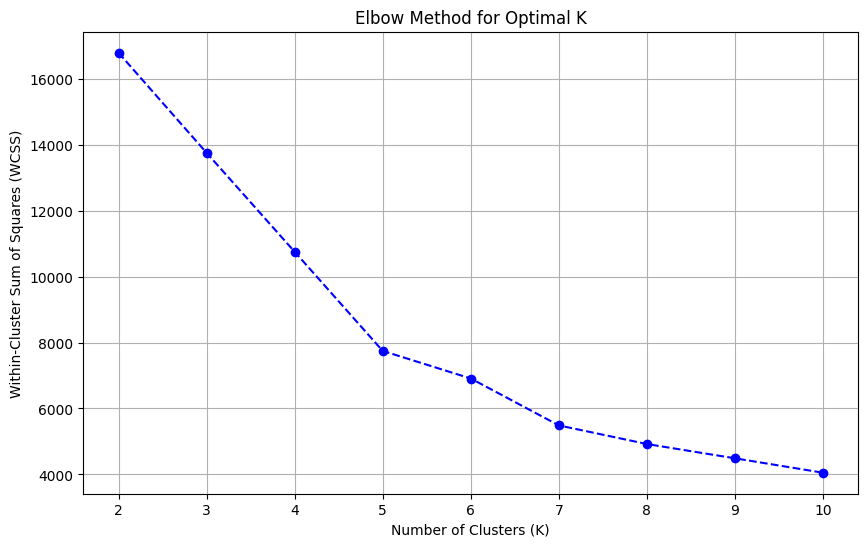

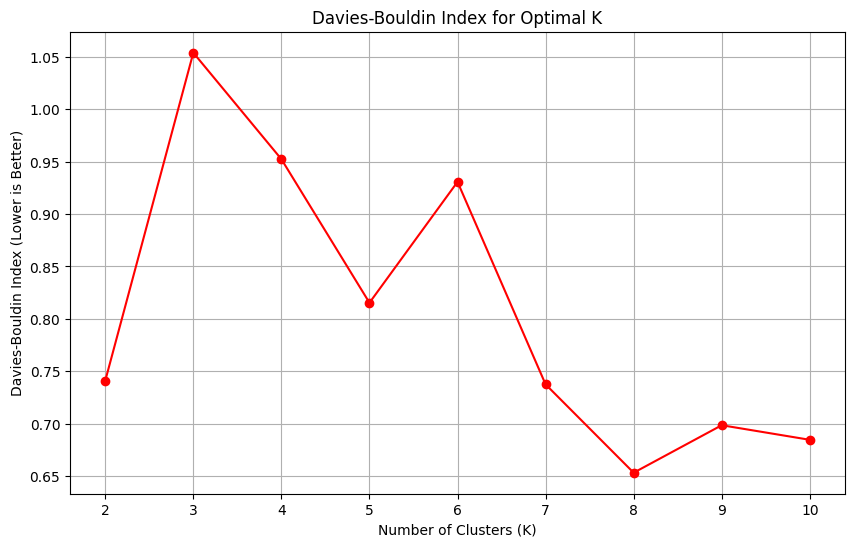

In [92]:
# Determine optimal number of clusters using the Elbow Method and Davies-Bouldin Index
wcss = []
dbi_scores = []
k_range = range(2, 11)  # Test 2 to 10 clusters

for k in k_range:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=30000, random_state=42)
    kmeans.fit(customer_df_scaled)

    # Elbow method: within-cluster sum of squares
    wcss.append(kmeans.inertia_)

    # Davies-Bouldin Index: lower is better
    dbi = davies_bouldin_score(customer_df_scaled, kmeans.labels_)
    dbi_scores.append(dbi)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Plot the Davies-Bouldin Index graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, dbi_scores, marker='o', linestyle='-', color='r')
plt.title('Davies-Bouldin Index for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index (Lower is Better)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [93]:
# Apply K-Means Clustering with K=5
from sklearn.cluster import KMeans

# Initialize KMeans with the chosen K (5)
# n_init='auto' is the modern default for n_init
kmeans = KMeans(n_clusters=5, init='k-means++', n_init='auto', max_iter=10000, random_state=42)

# Fit KMeans to the scaled data and get cluster labels
customer_df['Cluster_KMeans'] = kmeans.fit_predict(customer_df_scaled)

customer_df.head() # Display customer_df with the new Cluster_KMeans column

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans
CustomerID,,,,,,,
12347.0,1,7,4310.00,13.505495,103,Iceland,4
12348.0,74,4,1797.24,75.516129,22,Finland,4
12349.0,18,1,1757.55,8.643836,73,Italy,4
12350.0,309,1,334.40,11.588235,17,Norway,0
12352.0,35,6,1405.28,5.895522,51,Norway,4


In [94]:
# Analyze K-Means Cluster Characteristics
# Use customer_df (original, unscaled values) for meaningful averages
customer_df_unindexed = customer_df.reset_index()
kmeans_cluster_analysis = customer_df_unindexed.groupby('Cluster_KMeans').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count'), # Assuming CustomerID is now a regular column due to previous reset_index
    AvgQuantity=('AvgQuantity', 'mean'),
    AvgProductCount=('ProductCount', 'mean')
).sort_values(by='AvgMonetary', ascending=False) # Sort by Monetary for easier comparison

kmeans_cluster_analysis

,AvgRecency,AvgFrequency,AvgMonetary,CustomerCount,AvgQuantity,AvgProductCount
Cluster_KMeans,,,,,,
2,4.300000,95.300000,124751.664000,10,66.117109,810.500000
1,15.489933,14.378076,7192.546980,447,18.170842,209.006711
3,149.400000,1.900000,3600.771000,10,1879.350000,1.600000
4,45.294369,3.276907,1131.690069,2806,17.365458,49.088026
0,249.212928,1.562738,488.984383,1052,15.965712,24.032319


In [95]:
# Map K-Means Cluster IDs to descriptive names
# Assuming Cluster 0 is At-Risk/Lapsed
# Assuming Cluster 1 is Champions/Loyal
# Assuming Cluster 2 is Potential/Developing
cluster_name_mapping = {
    0: 'Dormant / At-Risk',
    1: 'Loyalist',
    2: 'VIP / Elite',
    3: 'One-Off Bulk Buyer',
    4: 'Occasional Shopper'
}

customer_df_unindexed['KMeans_Cluster_Name'] = customer_df_unindexed['Cluster_KMeans'].map(cluster_name_mapping)

customer_df_unindexed.head() # Display customer_df_unidexed with the new KMeans_Cluster_Name column

,CustomerID,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans,KMeans_Cluster_Name
0,12347.0,1,7,4310.00,13.505495,103,Iceland,4,Occasional Shopper
1,12348.0,74,4,1797.24,75.516129,22,Finland,4,Occasional Shopper
2,12349.0,18,1,1757.55,8.643836,73,Italy,4,Occasional Shopper
3,12350.0,309,1,334.40,11.588235,17,Norway,0,Dormant / At-Risk
4,12352.0,35,6,1405.28,5.895522,51,Norway,4,Occasional Shopper


In [96]:
# Count customers in each named K-Means cluster
customer_df_unindexed['KMeans_Cluster_Name'].value_counts()

,count
KMeans_Cluster_Name,
Occasional Shopper,2806
Dormant / At-Risk,1052
Loyalist,447
VIP / Elite,10
One-Off Bulk Buyer,10


# Segmentation Visualizations

In [97]:
# Create Interactive Cluster Summary Dashboard
# Features to compare
features = ["Recency", "Frequency", "Monetary", "AvgQuantity", "ProductCount"]

# Count of customers per cluster
cluster_counts = customer_df_unindexed["KMeans_Cluster_Name"].value_counts().reset_index()
cluster_counts.columns = ["KMeans_Cluster_Name", "Count"]

# Create 2x3 subplot grid
fig = sp.make_subplots(
    rows=2, cols=3,
    subplot_titles=["Customer Count per Cluster"] + features
)

# Create Bar Chart
bar = px.bar(
    cluster_counts,
    x="KMeans_Cluster_Name",
    y="Count",
    color="KMeans_Cluster_Name",
    text="Count"
)

# Make bars wider
bar.update_traces(width=0.6)

for trace in bar.data:
    fig.add_trace(trace, row=1, col=1)

# Add Boxplots for each feature
for i, col in enumerate(features):
    row = (i + 1) // 3 + 1
    col_pos = (i + 1) % 3 + 1
    box = px.box(
        customer_df_unindexed,
        x="KMeans_Cluster_Name",
        y=col,
        color="KMeans_Cluster_Name"
    )
    for trace in box.data:
        fig.add_trace(trace, row=row, col=col_pos)

# Layout adjustments
fig.update_layout(
    height=900,
    width=1200,
    title_text="Cluster Summary Dashboard",
    showlegend=False
)

fig.show()

In [98]:
# Create interactive 3d PCA Plot
# Features for PCA
features = ['Recency', 'Frequency', 'Monetary', 'AvgQuantity', 'ProductCount']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df_unindexed[features])

# PCA to reduce to 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Cluster_Name'] = customer_df_unindexed['KMeans_Cluster_Name']

# Interactive 3D scatter plot with Plotly
fig = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3',
    color='Cluster_Name',
    hover_data=['Cluster_Name'],
    size_max=10
)

fig.update_layout(
    title='Interactive 3D PCA Scatter Plot of Customer Clusters',
    legend_title='Cluster Name'
)

fig.show()